#  HI fluxes

Here we aim to explore the HI fluxes from different catalogs using [edge_pydb](https://github.com/tonywong94/edge_pydb)

1. edge_leda (647 entries, but 453 have fluxes)
2. edge_hiflux (161 entries; edge2015 and some more)
3. CALIFA_HI_sample_archive.csv (923 entries, 

4. FASHI (41741 entries)
5. ALFALFA  (31502 entries)

ALso of use

1. iEDGE (643 entries) - all properties
2. edge_califa (671 entries)

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from astropy.table import Table, join
from astropy import units as u
from edge_pydb import EdgeTable


In [2]:
EdgeTable('list')

Choose from the following files to read:
manga_global.csv
manga_global_dr15.csv
edge_bbpars_natv.csv
edge_jampars.csv
edge_rdist17.csv
edge_rfpars.csv
edge_bbpars_smo7.csv
ecalifa_global.csv
edge_califa.csv
edge_wise.csv
ecalifa_ned.csv
ecalifa_leda.csv
edge_leda.csv
.#edge_leda.csv
edge_ned.csv
edge_nsa.csv
edge_coflux_smo7.csv
edge_coflux_natv.csv
edge_coobs_DE.csv
junk.csv
edge_coobs_D.csv
edge_coflux_e20.csv
edge_coobs_E.csv
iedge_v1.csv
edge_hiflux.csv
NGC4047.cocube_smo7.hdf5
edge_cospec_e20.csv
edge_cospec_natv.csv
edge_cospec_smo7.csv
NGC4047_allpix.pipe3d.hdf5
rf_CO_natv.csv
rf_HA_smo6.csv
rf_HA_natv.csv
rf_CO_smo6.csv
rprof_de20_smo.csv
rprof_smo7_smo.csv
jam_rotcurves.csv
bb_natv_fitvd_dilmsk.csv
bb_natv_fitvd_dilmsk_freepa.csv
bb_natv_fixvd_dilmsk.csv
bb_smo7_fitvd_dilmsk.csv
bb_smo7_fitvd_dilmsk_freepa.csv
bb_smo7_fixvd_dilmsk_freepa.csv
bb_smo7_fixvd_dilmsk.csv
bb_natv_fixvd_dilmsk_freepa.csv
NGC4047_hex.2d_smo7.hdf5
NGC4047.2d_smo7.hdf5
EDGE_COparameters_20180515.csv
jam

<EdgeTable length=0>
<No columns>

In [3]:
# there's a "bug" in edge_pydb in that it doesn't recognize ecsv yet. I have a PR coming
if False:
    from edge_pydb import util
    util.updatefiles()
    EdgeTable('list')

In [4]:
#leda = pd.read_csv('edge_leda.csv')
#leda = np.loadtxt('edge_leda.csv', skiprows=1, delimiter=',')
#leda = np.genfromtxt('edge_leda.csv', skip_header=1, delimiter=',')
leda = EdgeTable('edge_leda.csv')

In [5]:
leda.info()


<EdgeTable length=647>
    name      dtype     unit   format                         description                            class     n_bad
------------ ------- --------- ------ ----------------------------------------------------------- ------------ -----
        Name   str23                                                                  Galaxy Name       Column     0
    ledaName   str23                                                 Galaxy name as known by LEDA       Column     0
      ledaRA float64       deg                                        RA J2000 from LEDA /al2000/       Column     0
      ledaDE float64       deg                                       DEC J2000 from LEDA /de2000/       Column     0
   ledaMorph    str4                                                 Hubble type from LEDA /type/ MaskedColumn     2
     ledaBar    str1                                              B = bar present from LEDA /bar/ MaskedColumn   354
    ledaRing    str1                     

In [6]:
# Name,ledaHIflux
idx = ~leda['ledaHIflux'].mask

# 453 galaxies (out of 647) have a flux
leda_haveflux = leda['Name'][idx]
leda_flux = leda['ledaHIflux'][idx]
#leda_flux


In [7]:
iedge = EdgeTable("iedge_v1.csv")

In [8]:
iedge.info()

<EdgeTable length=643>
         name           dtype           unit                                               description                                          class     n_bad
---------------------- ------- ---------------------- -------------------------------------------------------------------------------------- ------------ -----
           CALIFA_name   str22                                                    Name of the galaxy as indicated in the CALIFA extended DR3       Column     0
                 Alias   str27                                                                                Alternative name of the galaxy MaskedColumn     1
                    RA float64                    deg                                                   Right ascension of the galaxy centre       Column     0
                   DEC float64                    deg                                                       Declination of the galaxy centre       Column     0
                 

In [9]:
edge_hiflux = EdgeTable("edge_hiflux.csv")


In [10]:
edge_hiflux
# Name, SigInt, SigUnc
edge_hiflux['Name']


ARP220
IC0480
IC0540
IC0944
IC1151
IC1199
IC1256
IC1683
IC2247
IC2487
IC4566


In [11]:
califa = EdgeTable('edge_califa.csv')


In [12]:
califa

ID,Name,caSu,caSg,caSr,caSi,caB,caV,caR,caRe,caeRe,caEllipticity,caPA,caR50,caeR50,caR90,caeR90,cazgas,cazstars,caAge,caeAge,caAge_Re_fit,caeAge_Re_fit,caAge_alpha_fit,caeAge_alpha_fit,caAge_Re_fit_mw,caeAge_Re_fit_mw,caAge_alpha_fit_mw,caeAge_alpha_fit_mw,caFHa,caFHacorr,caLHacorr,caMstars,caeMstars,caMstarscorr,caSFR,caeSFR,caOH,caeOH,caOH_Re_fit,caeOH_Re_fit,caOH_alpha_fit,caeOH_alpha_fit,caOH_Re_fit_M08,caeOH_Re_fit_M08,caOH_alpha_fit_M08,caeOH_alpha_fit_M08,caAvgas,caeAvgas,caAvstars,caeAvstars,caDistP3d,caDistAng,caDistMpc,caFlgWav5,caFlgWav12,caFlgReg5,caFlgReg12,caFlgImg5,caFlgImg12
,,mag,mag,mag,mag,mag,mag,mag,arcsec,arcsec,,deg,arcsec,arcsec,arcsec,arcsec,,,dex(Gyr),dex(Gyr),dex(Gyr),dex(Gyr),dex(Gyr),dex(Gyr),dex(Gyr),dex(Gyr),dex(Gyr),dex(Gyr),dex(1e-16 erg / (s cm2)),dex(1e-16 erg / (s cm2)),dex(erg / s),dex(solMass),dex(solMass),dex(solMass),dex(solMass / yr),dex(solMass / yr),dex,dex,dex,dex,dex,dex,dex,dex,dex,dex,mag,mag,mag,mag,Mpc,Mpc,Mpc,,,,,,
int64,str23,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,IC5376,16.1851471079872,14.5148386558384,13.7746996210367,13.4152423076265,14.843331134221,14.109786555054,13.6956133607697,12.3533594260833,12.3533594260833,0.908298777642717,-86.6328412870503,14.5930861897852,0.580133286422324,39.8503507490289,0.0347700942141813,0.0166828002232699,0.0168304318230817,9.00921636199652,0.455905015787138,9.47029329320456,0.033373697585904,-0.424717157308448,0.0366186076544801,9.87122210809363,0.0158302942448841,-0.0113787373595571,0.0173694668538384,2.95946858763817,3.32444961005312,41.1168781882285,10.776715844314,0.104367367857885,10.7055607335975,0.0199681752204649,0.0595511264508334,8.50996204530593,0.0794470031628982,8.57379657876577,0.0135226263820659,-0.0479055738943362,0.0108332783268123,9.02900918200382,0.0205691008678075,0.0236736946644938,0.0164783665789037,1.39492131650746,0.151063952650176,0.5333289345863,0.984450288049397,71.98770098643776,69.62525974886516,72.39375643784535,0.0,0.0,0.0,1.0,0.0,0.0
2,UGC00005,15.2483065919008,14.1195941220309,13.5486392799929,13.2595749516228,14.3465821208416,13.8262788229319,13.4880400816455,20.2771195662004,20.2771195662004,0.836285736708902,-52.3187174424348,18.9515595557628,1.75042936323237,38.4605179219892,0.0280205074375317,0.0241986345275944,0.0241827738001353,8.91184972037966,0.412757304766495,9.15867209597674,0.0280138532930621,-0.344864900289066,0.0307376280374184,9.8270980548966,0.0281606451647009,-0.166789888636384,0.0308986924187496,3.43460867523136,3.88161456890663,41.993986953353,11.1192362635697,0.0854269039123404,11.0698528832268,0.897076940344901,0.05940876117232,8.54536704605116,0.0742684265982679,8.58715267366793,0.0200015718577077,-0.0190936711875484,0.0168108632339188,9.10676727932215,0.0400938510361776,-0.132170039440426,0.0336979638943007,1.5306335152532,0.106462160317965,0.309254153553231,0.693342148396912,104.04715441810822,99.19252656489616,105.62120034645841,0.0,0.0,0.0,0.0,0.0,0.0
3,NGC7819,15.4603954062173,14.5798509052481,14.1126097805191,13.9201432971941,14.761192584692,14.340216858187,14.0808253870926,15.1049879351976,15.1049879351976,0.871362684327647,-29.8714123412653,23.0121743761998,0.809684503319659,43.7792585693556,0.289541672473945,0.0164932924713098,0.016484375328998,8.67553505306613,0.366263582536238,9.02978353018453,0.0255296907157498,0.0856600971823328,0.0280119314155684,9.73051308519857,0.0495427404712661,-0.219286511077027,0.0543597595314485,3.46625134981103,3.71457429825972,41.4891312282872,10.4262028993743,0.0821361191644355,10.4755058428902,0.392221215279186,0.06004851420

## LEDA vs. EDGE

Take all edge_leda galaxies which have a known flux (no error bars available). Then find the flux in edge_hiflux for those galaxies

In [13]:
leda = EdgeTable('edge_leda.csv', cols=['Name', 'ledaHIflux'])

In [14]:
edge_hiflux = EdgeTable("edge_hiflux.csv", cols=['Name', 'SigInt', 'SigUnc'])

In [15]:
leda.join(edge_hiflux)
len(leda)

159

In [16]:
leda.keys()
print(leda)

  Name   ledaHIflux   SigInt    SigUnc 
         Jy km / s  Jy km / s Jy km / s
-------- ---------- --------- ---------
  ARP220      18.30  -15.3437  0.337894
  IC0480       5.67   4.36842 0.0515789
  IC0540       1.35   1.29401 0.0845692
  IC0944       3.59   2.50588  0.121696
  IC1151      10.63   7.97362 0.0978262
  IC1199       3.63  0.336397  0.327774
  IC1256       7.68   9.05259 0.0989509
  IC1683       1.23  0.768299 0.0746721
  IC2247       3.39   3.28419   0.06471
     ...        ...       ...       ...
UGC10257       6.30   7.39802  0.188372
UGC10297       3.90   3.51746  0.119967
UGC10331       4.29   5.86987 0.0588958
UGC10337       2.88    2.8539  0.112012
UGC10380       3.56   4.10167  0.159646
UGC10384       8.11   7.79214 0.0679349
UGC10650       3.31   4.20422  0.190008
UGC10710       3.96   3.74559  0.120014
UGC10972       7.18   8.39796  0.134901
UGC12864       8.93   10.6954    0.2431
Length = 159 rows


Text(0, 0.5, 'EDGE_HIFLUX')

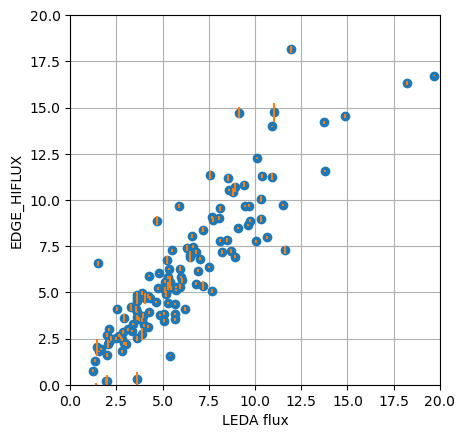

In [17]:
fig, ax = plt.subplots()
ax.plot(leda['ledaHIflux'], leda['SigInt'], 'o')
ax.errorbar(leda['ledaHIflux'], leda['SigInt'], yerr=leda['SigUnc'],ls='none')
fmin = 0
fmax = 20
ax.set_xlim(fmin,fmax)
ax.set_ylim(fmin,fmax)
ax.grid()
ax.set_aspect('equal')
ax.plot([fmin,fmin],[fmax,fmax],'-', color='red')
ax.set_xlabel("LEDA flux")
ax.set_ylabel("EDGE_HIFLUX")